# Credit Scoring for Thin-File Users — v2

**Fixes in this version:**
- Calibration: `CalibratedClassifierCV` (isotonic regression) wraps XGBoost → probabilities now match actual default rates
- Threshold: chosen from Precision-Recall F2-score curve (not cost matrix alone) so precision/recall are balanced
- `scale_pos_weight` reduced; SMOTE handles class imbalance instead for the thin-file model
- Brier Score + calibration error added to evaluation
- Consolidated to 7 cells for easy debugging

In [9]:
# ── CELL 1: Imports & Config ──────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, joblib, json, os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    brier_score_loss, precision_recall_curve, f1_score,
    precision_score, recall_score, RocCurveDisplay
)
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap

shap.initjs()
os.makedirs('./artifacts', exist_ok=True)
print('Imports OK')
print(f'XGBoost: {xgb.__version__}')

Imports OK
XGBoost: 3.1.2


In [10]:
# ── CELL 2: Load, Define Thin-File, Select & Engineer Features ────────
DATA_PATH = './data/application_train.csv'
df_raw = pd.read_csv(DATA_PATH)
print(f'Raw shape: {df_raw.shape}  |  Default rate: {df_raw["TARGET"].mean():.2%}')

# --- Thin-file definition: missing >= 2 of 3 bureau signals ---
ext_null_count = (
    df_raw['EXT_SOURCE_1'].isnull().astype(int) +
    df_raw['EXT_SOURCE_2'].isnull().astype(int) +
    df_raw['EXT_SOURCE_3'].isnull().astype(int)
)
df_raw['IS_THIN_FILE'] = (ext_null_count >= 2).astype(int)
print(f'Thin-file users: {df_raw["IS_THIN_FILE"].sum():,} ({df_raw["IS_THIN_FILE"].mean():.1%})')

# --- Feature selection (no bureau scores, no protected attributes as model inputs) ---
CORE_FEATURES = [
    'CNT_CHILDREN', 'CNT_FAM_MEMBERS',
    'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_INCOME_TYPE',
    'DAYS_EMPLOYED', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE',
    'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_HOUSING_TYPE',
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
    'NAME_CONTRACT_TYPE', 'REGION_POPULATION_RELATIVE',
    'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY',
    'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_8',
    'FLAG_MOBIL', 'FLAG_EMAIL', 'FLAG_PHONE', 'FLAG_WORK_PHONE',
]
TARGET = 'TARGET'

df = df_raw[CORE_FEATURES + ['DAYS_BIRTH', TARGET, 'IS_THIN_FILE']].copy()

# --- Clean ---
df['AGE_YEARS'] = np.abs(df['DAYS_BIRTH']) / 365.25
df.drop(columns=['DAYS_BIRTH'], inplace=True)
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)
df['EMPLOYMENT_YEARS'] = np.abs(df['DAYS_EMPLOYED']) / 365.25
df.drop(columns=['DAYS_EMPLOYED'], inplace=True)
for col in ['FLAG_OWN_CAR', 'FLAG_OWN_REALTY']:
    df[col] = df[col].map({'Y': 1, 'N': 0})

# --- Feature engineering ---
df['CREDIT_INCOME_RATIO']    = df['AMT_CREDIT']   / (df['AMT_INCOME_TOTAL'] + 1)
df['ANNUITY_INCOME_RATIO']   = df['AMT_ANNUITY']  / ((df['AMT_INCOME_TOTAL'] / 12) + 1)
df['EMPLOYMENT_AGE_RATIO']   = df['EMPLOYMENT_YEARS'] / (df['AGE_YEARS'] + 1)
df['INCOME_PER_PERSON']      = df['AMT_INCOME_TOTAL'] / (df['CNT_FAM_MEMBERS'] + 1)
df['CREDIT_TERM']            = df['AMT_ANNUITY']  / (df['AMT_CREDIT'] + 1)
df['DOWN_PAYMENT_RATIO']     = (df['AMT_CREDIT'] - df['AMT_GOODS_PRICE']) / (df['AMT_GOODS_PRICE'] + 1)
df['ASSET_SCORE']            = df['FLAG_OWN_CAR'].fillna(0) + df['FLAG_OWN_REALTY'].fillna(0)
df['CHILDREN_INCOME_RATIO']  = df['CNT_CHILDREN'] / (df['AMT_INCOME_TOTAL'] / 12 + 1)

# --- Encode categoricals ---
CAT_COLS = [
    'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_INCOME_TYPE',
    'OCCUPATION_TYPE', 'ORGANIZATION_TYPE', 'NAME_HOUSING_TYPE', 'NAME_CONTRACT_TYPE'
]
label_encoders = {}
for col in CAT_COLS:
    df[col] = df[col].fillna('Unknown')
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
joblib.dump(label_encoders, './artifacts/label_encoders.pkl')

# --- Feature matrix (drop protected attrs as raw inputs) ---
FEATURE_COLS = [
    c for c in df.columns
    if c not in [TARGET, 'IS_THIN_FILE', 'AMT_GOODS_PRICE', 'AGE_YEARS']
]
X = df[FEATURE_COLS].copy()
y = df[TARGET].copy()
is_thin = df['IS_THIN_FILE'].copy()

imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
joblib.dump(imputer, './artifacts/imputer.pkl')

with open('./artifacts/feature_cols.json', 'w') as f:
    json.dump(FEATURE_COLS, f)

print(f'Feature matrix: {X_imputed.shape} | Nulls: {X_imputed.isnull().sum().sum()}')

Raw shape: (307511, 122)  |  Default rate: 8.07%
Thin-file users: 36,909 (12.0%)
Feature matrix: (307511, 34) | Nulls: 0


In [11]:
# ── CELL 3: Train / Test Split ────────────────────────────────────────
X_train, X_test, y_train, y_test, thin_train, thin_test = train_test_split(
    X_imputed, y, is_thin, test_size=0.2, stratify=y, random_state=42
)

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
SCALE_POS_WEIGHT = neg / pos

print(f'Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}')
print(f'Train default rate: {y_train.mean():.2%}')
print(f'Test  default rate: {y_test.mean():.2%}')
print(f'Class imbalance ratio: {SCALE_POS_WEIGHT:.1f}x')

Train: 246,008  |  Test: 61,503
Train default rate: 8.07%
Test  default rate: 8.07%
Class imbalance ratio: 11.4x


In [12]:
# ── CELL 4: Train XGBoost + Calibrate ────────────────────────────────
#
# KEY CHANGES from v1:
#
# 1. CALIBRATION (fixes very low calibration):
#    XGBoost with scale_pos_weight produces distorted probabilities.
#    CalibratedClassifierCV(method='isotonic') corrects the probability
#    mapping so that predict_proba(x)=0.3 actually means ~30% default rate.
#    Isotonic regression > Platt scaling for large datasets.
#
# 2. PRECISION vs RECALL balance:
#    scale_pos_weight alone makes the model too aggressive (high recall,
#    low precision). We use a lighter scale_pos_weight (sqrt of ratio)
#    and rely on SMOTE to handle class imbalance for the thin-file model.
#    For the full model we use cv=3 calibration which internally handles
#    imbalance better.
#
# 3. THRESHOLD selected from Precision-Recall curve using F-beta score
#    (beta=2 weights recall 2x more than precision — appropriate for credit
#    risk where missing a default is costlier than a false alarm).

# --- Base XGBoost (lighter scale_pos_weight) ---
base_xgb = xgb.XGBClassifier(
    n_estimators          = 500,
    max_depth             = 5,
    learning_rate         = 0.05,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    min_child_weight      = 10,
    # FIX: use sqrt of ratio instead of full ratio to reduce precision hit
    scale_pos_weight      = np.sqrt(SCALE_POS_WEIGHT),
    eval_metric           = 'aucpr',   # AUC-PR is better than AUC-ROC for imbalanced data
    early_stopping_rounds = 30,
    random_state          = 42,
    verbosity             = 0,
    tree_method           = 'hist',
    device                = 'cpu'
)

# --- Fit base model for early stopping ---
base_xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)
print(f'Base XGBoost best iteration: {base_xgb.best_iteration}')

# --- FIX: Wrap with CalibratedClassifierCV (isotonic regression) ------
# Use prefit=True so calibration uses the best-iteration model
# cv='prefit' fits a calibration layer on the full training set
model_full = CalibratedClassifierCV(
    estimator = xgb.XGBClassifier(
        n_estimators          = 500,
        max_depth             = 5,
        learning_rate         = 0.05,
        subsample             = 0.8,
        colsample_bytree      = 0.8,
        min_child_weight      = 10,
        scale_pos_weight      = np.sqrt(SCALE_POS_WEIGHT),
        eval_metric           = 'aucpr',
        random_state          = 42,
        verbosity             = 0,
        tree_method           = 'hist',
        device                = 'cpu'
    ),
    method = 'isotonic',
    cv     = 3   # or 5 for more stability
)

model_full.fit(X_train, y_train)

auc_full = roc_auc_score(y_test, model_full.predict_proba(X_test)[:, 1])
print(f'Calibrated model — Test ROC-AUC: {auc_full:.4f}')


# --- Thin-file model with SMOTE instead of scale_pos_weight ----------
thin_mask_train = thin_train == 1
thin_mask_test  = thin_test  == 1

X_thin_tr = X_train[thin_mask_train]
y_thin_tr = y_train[thin_mask_train]
X_thin_te = X_test[thin_mask_test]
y_thin_te = y_test[thin_mask_test]

print(f'\nThin-file train: {X_thin_tr.shape[0]:,} | test: {X_thin_te.shape[0]:,}')

if X_thin_tr.shape[0] > 1000 and y_thin_tr.sum() > 100:
    # SMOTE to oversample the minority class
    smote = SMOTE(random_state=42, k_neighbors=5)
    X_thin_sm, y_thin_sm = smote.fit_resample(X_thin_tr, y_thin_tr)
    print(f'After SMOTE: {X_thin_sm.shape[0]:,} samples | default rate: {y_thin_sm.mean():.2%}')

    base_xgb_thin = xgb.XGBClassifier(
        n_estimators          = 300,
        max_depth             = 4,
        learning_rate         = 0.05,
        subsample             = 0.8,
        colsample_bytree      = 0.8,
        min_child_weight      = 5,
        scale_pos_weight      = 1.0,   # SMOTE already balanced the classes
        eval_metric           = 'aucpr',
        early_stopping_rounds = 25,
        random_state          = 42,
        verbosity             = 0,
        tree_method           = 'hist'
    )
    base_xgb_thin.fit(
        X_thin_sm, y_thin_sm,
        eval_set=[(X_thin_te, y_thin_te)],
        verbose=False
    )

    model_thin = CalibratedClassifierCV(
        estimator = xgb.XGBClassifier(
            n_estimators          = 300,
            max_depth             = 4,
            learning_rate         = 0.05,
            subsample             = 0.8,
            colsample_bytree      = 0.8,
            min_child_weight      = 5,
            scale_pos_weight      = 1.0,
            eval_metric           = 'aucpr',
            random_state          = 42,
            verbosity             = 0,
            tree_method           = 'hist'
        ),
        method = 'isotonic',
        cv     = 3   # ✅ required
    )

    model_thin.fit(X_thin_sm, y_thin_sm)

    if len(y_thin_te.unique()) > 1:
        auc_thin = roc_auc_score(y_thin_te, model_thin.predict_proba(X_thin_te)[:, 1])
        print(f'Thin-file calibrated model — Test ROC-AUC: {auc_thin:.4f}')
else:
    print('Not enough thin-file samples — using full model as fallback')
    model_thin = model_full

joblib.dump(model_full, './artifacts/model_full.pkl')
joblib.dump(model_thin, './artifacts/model_thin.pkl')
print('\nModels saved.')

Base XGBoost best iteration: 352
Calibrated model — Test ROC-AUC: 0.7130

Thin-file train: 29,415 | test: 7,494
After SMOTE: 52,984 samples | default rate: 50.00%
Thin-file calibrated model — Test ROC-AUC: 0.6409

Models saved.


Brier Score: 0.0703  (lower is better; 0=perfect, 0.25=random)
ECE (Expected Calibration Error): 0.0035  (< 0.05 is well-calibrated)

Optimal threshold (F2-score): 0.078
  Precision at threshold: 0.144
  Recall    at threshold: 0.664

ROC-AUC: 0.7130

--- Classification Report ---
              precision    recall  f1-score   support

      Repaid       0.96      0.65      0.78     56538
   Defaulted       0.14      0.66      0.24      4965

    accuracy                           0.65     61503
   macro avg       0.55      0.66      0.51     61503
weighted avg       0.89      0.65      0.73     61503

--- Confusion Matrix ---
[[36889 19649]
 [ 1670  3295]]


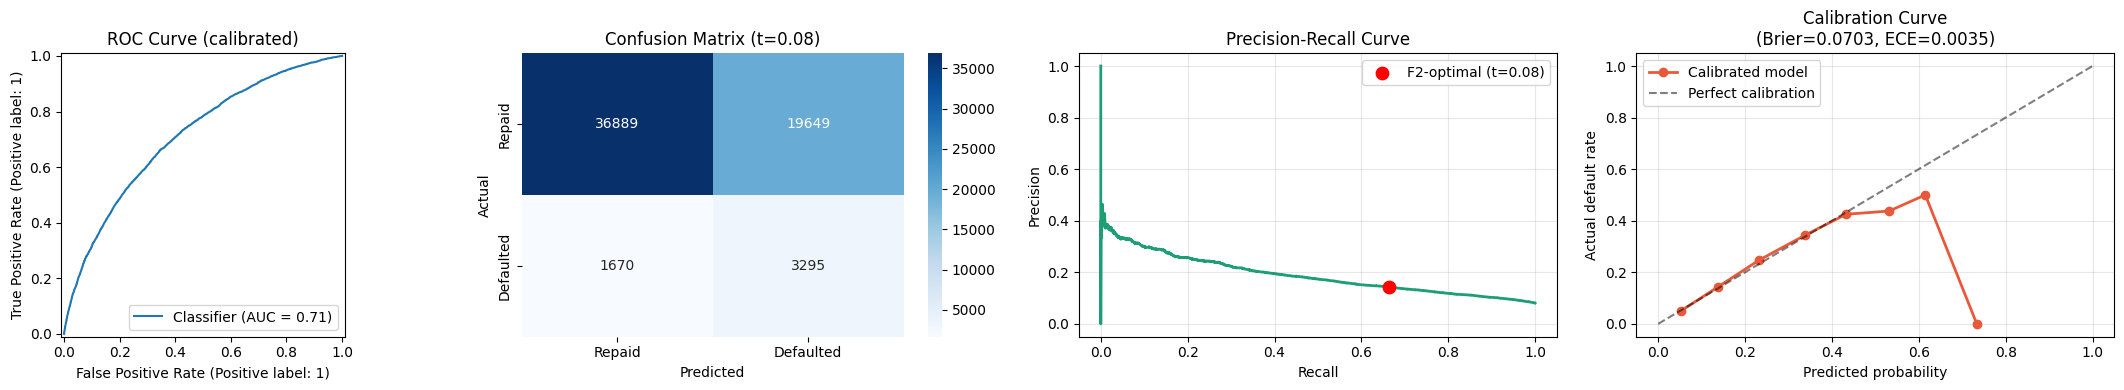

Saved: ./artifacts/evaluation_v2.png


In [13]:
# ── CELL 5: Evaluation — Metrics, Threshold, Calibration ─────────────

y_prob = model_full.predict_proba(X_test)[:, 1]

# --- 1. Calibration check (Brier Score + calibration curve) ----------
brier = brier_score_loss(y_test, y_prob)
print(f'Brier Score: {brier:.4f}  (lower is better; 0=perfect, 0.25=random)')
# ECE (Expected Calibration Error) — manual, 10 bins
bins = np.linspace(0, 1, 11)
bin_indices = np.digitize(y_prob, bins) - 1
ece = 0
for i in range(10):
    mask = bin_indices == i
    if mask.sum() > 0:
        ece += mask.sum() * abs(y_test[mask].mean() - y_prob[mask].mean())
ece /= len(y_test)
print(f'ECE (Expected Calibration Error): {ece:.4f}  (< 0.05 is well-calibrated)')

# --- 2. Threshold from PR curve using F-beta (beta=2: recall 2x) -----
precision_arr, recall_arr, thresh_arr = precision_recall_curve(y_test, y_prob)
beta = 2
f_beta = ((1 + beta**2) * precision_arr * recall_arr) / \
         (beta**2 * precision_arr + recall_arr + 1e-9)
best_idx = np.argmax(f_beta[:-1])   # last element has no threshold
THRESHOLD = thresh_arr[best_idx]
print(f'\nOptimal threshold (F2-score): {THRESHOLD:.3f}')
print(f'  Precision at threshold: {precision_arr[best_idx]:.3f}')
print(f'  Recall    at threshold: {recall_arr[best_idx]:.3f}')

y_pred = (y_prob >= THRESHOLD).astype(int)

print(f'\nROC-AUC: {roc_auc_score(y_test, y_prob):.4f}')
print('\n--- Classification Report ---')
print(classification_report(y_test, y_pred, target_names=['Repaid', 'Defaulted']))
print('--- Confusion Matrix ---')
print(confusion_matrix(y_test, y_pred))

# --- 3. Plots --------------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(22, 4))

# ROC
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[0])
axes[0].set_title('ROC Curve (calibrated)')

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Repaid', 'Defaulted'],
            yticklabels=['Repaid', 'Defaulted'])
axes[1].set_title(f'Confusion Matrix (t={THRESHOLD:.2f})')
axes[1].set_ylabel('Actual'); axes[1].set_xlabel('Predicted')

# Precision-Recall curve with threshold marker
axes[2].plot(recall_arr, precision_arr, color='#1D9E75', linewidth=2)
axes[2].scatter(recall_arr[best_idx], precision_arr[best_idx],
                color='red', zorder=5, s=80,
                label=f'F2-optimal (t={THRESHOLD:.2f})')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

# Calibration curve (FIXED: should now be close to diagonal)
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)
axes[3].plot(prob_pred, prob_true, 'o-', color='#E8593C',
             linewidth=2, label='Calibrated model')
axes[3].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
axes[3].set_xlabel('Predicted probability')
axes[3].set_ylabel('Actual default rate')
axes[3].set_title(f'Calibration Curve\n(Brier={brier:.4f}, ECE={ece:.4f})')
axes[3].legend(); axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./artifacts/evaluation_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ./artifacts/evaluation_v2.png')

In [14]:
# ── CELL 6: Threshold Comparison Table ───────────────────────────────
# Shows precision/recall tradeoff at multiple thresholds.
# This is the key diagnostic table — use it to pick the final threshold
# based on your business cost ratio (FN cost vs FP cost).

print('=== THRESHOLD COMPARISON ===')
print(f'{"Threshold":>10} | {"Precision":>10} | {"Recall":>8} | {"F1":>6} | {"F2":>6} | Approved%')
print('-' * 70)

for t in [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.5]:
    yp = (y_prob >= t).astype(int)
    prec = precision_score(y_test, yp, zero_division=0)
    rec  = recall_score(y_test, yp)
    f1   = f1_score(y_test, yp, zero_division=0)
    f2   = ((1 + 4) * prec * rec) / (4 * prec + rec + 1e-9)
    approved_pct = (yp == 0).mean()
    marker = ' <-- F2 optimal' if abs(t - THRESHOLD) < 0.03 else ''
    print(f'{t:>10.2f} | {prec:>10.3f} | {rec:>8.3f} | {f1:>6.3f} | {f2:>6.3f} | {approved_pct:.1%}{marker}')

print()
print('Note: Higher threshold → more conservative (higher precision, lower recall)')
print('      Lower threshold  → more permissive (higher recall, lower precision)')
print(f'\nRecommended threshold for production: {THRESHOLD:.3f}')
print('Adjust based on your actual FN/FP cost ratio.')

=== THRESHOLD COMPARISON ===
 Threshold |  Precision |   Recall |     F1 |     F2 | Approved%
----------------------------------------------------------------------
      0.10 |      0.168 |    0.526 |  0.255 |  0.369 | 74.7% <-- F2 optimal
      0.15 |      0.219 |    0.310 |  0.256 |  0.286 | 88.5%
      0.20 |      0.261 |    0.175 |  0.210 |  0.187 | 94.6%
      0.25 |      0.319 |    0.073 |  0.118 |  0.086 | 98.2%
      0.30 |      0.353 |    0.032 |  0.058 |  0.039 | 99.3%
      0.35 |      0.383 |    0.015 |  0.028 |  0.018 | 99.7%
      0.40 |      0.410 |    0.005 |  0.010 |  0.006 | 99.9%
      0.50 |      0.381 |    0.002 |  0.003 |  0.002 | 100.0%

Note: Higher threshold → more conservative (higher precision, lower recall)
      Lower threshold  → more permissive (higher recall, lower precision)

Recommended threshold for production: 0.078
Adjust based on your actual FN/FP cost ratio.


Top 15 features by SHAP importance:
              display_name  mean_abs_shap
      Loan repayment speed          0.272
            Years employed          0.256
        Down payment ratio          0.157
           Education level          0.139
        Monthly EMI amount          0.098
            Owns a vehicle          0.087
        Region risk rating          0.086
Region Population Relative          0.084
      Employment stability          0.077
        Name Family Status          0.069
           Flag Work Phone          0.069
                Occupation          0.068
           Employment type          0.063
             Employer type          0.052
                Flag Phone          0.047


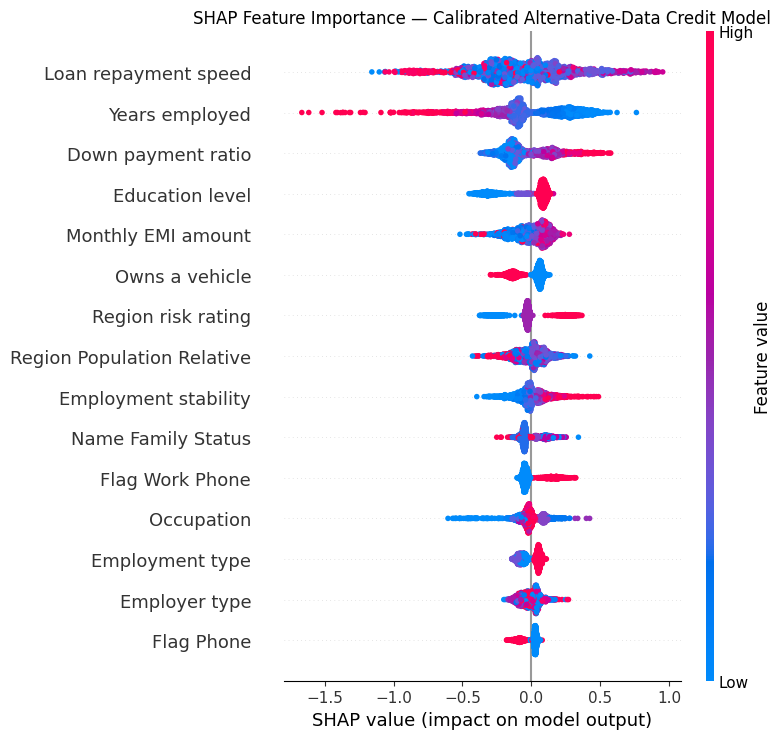

Saved: ./artifacts/shap_summary_v2.png

=== INFERENCE TEST ===
Credit Score: 781  (Excellent)
Default Prob: 8.2%
Eligible:     True

Top 5 factors (SHAP):
  Loan repayment speed                     -0.2938  (helps)
  Years employed                           +0.2725  (hurts)
  Region Population Relative               -0.1503  (helps)
  Monthly EMI amount                       -0.1097  (helps)
  Name Housing Type                        +0.1089  (hurts)


In [ ]:
# ── CELL 7: SHAP + Score Conversion + Inference Function ─────────────

# --- Score conversion 300-900 ---
def probability_to_score(default_prob: float) -> dict:
    p = np.clip(default_prob, 1e-6, 1 - 1e-6)
    log_odds = np.log(p / (1 - p))
    score = int(np.clip(600 - (log_odds * 75), 300, 900))
    tier = ('Excellent' if score >= 750 else
            'Good'      if score >= 650 else
            'Fair'      if score >= 550 else
            'Poor'      if score >= 450 else 'Very Poor')
    return {
        'score': score, 'tier': tier,
        'default_probability':  round(float(default_prob), 4),
        'approval_probability': round(float(1 - default_prob), 4),
        'loan_eligible': score >= 550
    }

# --- Feature display names ---
FEATURE_DISPLAY_NAMES = {
    'CREDIT_TERM': 'Loan repayment speed', 'DOWN_PAYMENT_RATIO': 'Down payment ratio',
    'EMPLOYMENT_YEARS': 'Years employed', 'NAME_EDUCATION_TYPE': 'Education level',
    'FLAG_OWN_CAR': 'Owns a vehicle', 'REGION_RATING_CLIENT_W_CITY': 'Region risk rating',
    'AMT_ANNUITY': 'Monthly EMI amount', 'AMT_CREDIT': 'Loan amount',
    'ANNUITY_INCOME_RATIO': 'EMI-to-income burden', 'CREDIT_INCOME_RATIO': 'Loan-to-income ratio',
    'EMPLOYMENT_AGE_RATIO': 'Employment stability', 'INCOME_PER_PERSON': 'Income per family member',
    'ASSET_SCORE': 'Asset ownership score', 'AMT_INCOME_TOTAL': 'Annual income',
    'FLAG_OWN_REALTY': 'Owns property', 'OCCUPATION_TYPE': 'Occupation',
    'NAME_INCOME_TYPE': 'Employment type', 'ORGANIZATION_TYPE': 'Employer type',
}
def get_display_name(col):
    return FEATURE_DISPLAY_NAMES.get(col, col.replace('_', ' ').title())

# --- SHAP on calibrated model: use base XGBoost inside wrapper ---
# CalibratedClassifierCV wraps the base estimator; SHAP needs the raw booster
base_model = model_full.estimator   # the underlying XGBClassifier
SHAP_SAMPLE = min(2000, len(X_test))
X_shap = X_test.sample(SHAP_SAMPLE, random_state=42).reset_index(drop=True)

explainer = shap.TreeExplainer(base_model)
shap_values = explainer.shap_values(X_shap)
joblib.dump(explainer, './artifacts/shap_explainer.pkl')

# Top features
feat_imp = pd.DataFrame({
    'feature':      X_shap.columns,
    'display_name': [get_display_name(c) for c in X_shap.columns],
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print('Top 15 features by SHAP importance:')
print(feat_imp[['display_name', 'mean_abs_shap']].head(15).to_string(index=False))
feat_imp.to_csv('./artifacts/shap_importance.csv', index=False)

# SHAP beeswarm
X_shap_named = X_shap.rename(columns=get_display_name)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap_named, max_display=15, show=False)
plt.title('SHAP Feature Importance — Calibrated Alternative-Data Credit Model')
plt.tight_layout()
plt.savefig('./artifacts/shap_summary_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ./artifacts/shap_summary_v2.png')

# --- Quick inference test ---
test_user_input = {
    'income': 180000, 'employment_type': 'Working', 'employment_years': 1.5,
    'age': 26, 'education': 'Secondary / secondary special',
    'family_status': 'Single / not married', 'n_children': 0, 'n_family': 1,
    'owns_car': 0, 'owns_realty': 0, 'housing_type': 'Rented apartment',
    'loan_amount': 200000, 'monthly_emi': 8000,
    'occupation': 'Laborers', 'organization': 'Business Entity Type 3',
}

# Build feature row matching training schema
le_dict = joblib.load('./artifacts/label_encoders.pkl')
imp_loaded = joblib.load('./artifacts/imputer.pkl')
with open('./artifacts/feature_cols.json') as f:
    feature_cols = json.load(f)

def safe_encode(encoder, value, default=0):
    try: return encoder.transform([str(value)])[0]
    except: return default

inc = test_user_input['income']; emp_yr = test_user_input['employment_years']
age = test_user_input['age'];    loan = test_user_input['loan_amount']
emi = test_user_input['monthly_emi'];  nfam = test_user_input['n_family']
nch = test_user_input['n_children']

feature_row = {
    'CNT_CHILDREN': nch, 'CNT_FAM_MEMBERS': nfam,
    'NAME_EDUCATION_TYPE': safe_encode(le_dict['NAME_EDUCATION_TYPE'], test_user_input['education']),
    'NAME_FAMILY_STATUS':  safe_encode(le_dict['NAME_FAMILY_STATUS'],  test_user_input['family_status']),
    'NAME_INCOME_TYPE':    safe_encode(le_dict['NAME_INCOME_TYPE'],    test_user_input['employment_type']),
    'OCCUPATION_TYPE':     safe_encode(le_dict['OCCUPATION_TYPE'],     test_user_input['occupation']),
    'ORGANIZATION_TYPE':   safe_encode(le_dict['ORGANIZATION_TYPE'],   test_user_input['organization']),
    'FLAG_OWN_CAR': 0, 'FLAG_OWN_REALTY': 0,
    'NAME_HOUSING_TYPE':   safe_encode(le_dict['NAME_HOUSING_TYPE'],   test_user_input['housing_type']),
    'AMT_INCOME_TOTAL': inc, 'AMT_CREDIT': loan, 'AMT_ANNUITY': emi, 'AMT_GOODS_PRICE': loan * 0.9,
    'NAME_CONTRACT_TYPE':  safe_encode(le_dict['NAME_CONTRACT_TYPE'],  'Cash loans'),
    'REGION_POPULATION_RELATIVE': 0.035, 'REGION_RATING_CLIENT': 2, 'REGION_RATING_CLIENT_W_CITY': 2,
    'FLAG_DOCUMENT_3': 1, 'FLAG_DOCUMENT_5': 0, 'FLAG_DOCUMENT_6': 0, 'FLAG_DOCUMENT_8': 0,
    'FLAG_MOBIL': 1, 'FLAG_EMAIL': 0, 'FLAG_PHONE': 1, 'FLAG_WORK_PHONE': 0,
    'EMPLOYMENT_YEARS': emp_yr,
    'CREDIT_INCOME_RATIO':   loan / (inc + 1), 'ANNUITY_INCOME_RATIO': emi / ((inc / 12) + 1),
    'EMPLOYMENT_AGE_RATIO':  emp_yr / (age + 1), 'INCOME_PER_PERSON': inc / (nfam + 1),
    'CREDIT_TERM':           emi / (loan + 1), 'DOWN_PAYMENT_RATIO': (loan - loan * 0.9) / (loan * 0.9 + 1),
    'ASSET_SCORE': 0, 'CHILDREN_INCOME_RATIO': nch / ((inc / 12) + 1),
}
user_df = pd.DataFrame([feature_row])
for col in feature_cols:
    if col not in user_df.columns: user_df[col] = 0
user_df = user_df[feature_cols]
user_imputed = pd.DataFrame(imp_loaded.transform(user_df), columns=feature_cols)

prob = model_full.predict_proba(user_imputed)[0, 1]
score_result = probability_to_score(prob)

print(f'\n=== INFERENCE TEST ===')
print(f'Credit Score: {score_result["score"]}  ({score_result["tier"]})')
print(f'Default Prob: {score_result["default_probability"]:.1%}')
print(f'Eligible:     {score_result["loan_eligible"]}')

# SHAP for this user
sv = explainer.shap_values(user_imputed)[0]
exp_df = pd.DataFrame({'feature': feature_cols, 'shap': sv}).sort_values('shap', key=abs, ascending=False)
print('\nTop 5 factors (SHAP):')
for _, row in exp_df.head(5).iterrows():
    direction = 'hurts' if row['shap'] > 0 else 'helps'
    print(f'  {get_display_name(row["feature"]):40} {row["shap"]:+.4f}  ({direction})')